Implementation of Neural optimal stopping boundary, A. Max Reppen and H. Mete Soner and Valentin Tissot-Daguette

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
DEBUG = 0 #0, 1, 2

In [3]:
# --- Network definition ---
class StoppingBoundaryNet(nn.Module):
    def __init__(self, latent_dim, bias_init):
        super().__init__()
        hidden_units = 20 + latent_dim
        self.dense1 = nn.Linear(1 + latent_dim, hidden_units)  #1 + latent_dim for t and xi
        self.dense2 = nn.Linear(hidden_units, hidden_units)
        self.out_dense = nn.Linear(hidden_units, 1, bias=False)
        self.bias = nn.Parameter(torch.tensor([bias_init], dtype=torch.float32))

    def forward(self, t, xi):
        x = torch.cat([t, xi], dim=1)
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        return F.relu(self.out_dense(x) + self.bias)

In [4]:
def fuzzy_stop_probs(alpha, f_vals, eta, eps): #see 3.1
    d = eta * (f_vals - alpha)
    return torch.clamp((eps - d) / (2.0 * eps), min=0.0, max=1.0)


def train_step(model, optimizer, paths, t_grid, alpha_fn, Xi_fn, phi_fn, eta, eps, r):
    """
    
    Args:
        - alpha_fn: coordinate function used to transform the state variable into a representation suitable for defining the stopping region
        - Xi_fn: function that returns the latent variable xi, which is used to define the stopping boundary
        - phi_fn: function that computes the payoff for the option at a given time and state
    """
    model.train()
    B = paths.shape[0]
    b = torch.ones((B, 1), dtype=torch.float32)
    reward = torch.zeros((B, 1), dtype=torch.float32)

    for i, t in enumerate(t_grid[:-1]):
        t_tensor = torch.full((B, 1), t, dtype=torch.float32)
        x = paths[:, i, :]
        alpha_x = alpha_fn(x)
        xi = Xi_fn(x)
        f_val = model(t_tensor, xi)
        p = fuzzy_stop_probs(alpha_x, f_val, eta, eps)
        phi = phi_fn(t, x, r)
        reward += p * b * phi
        b = b * (1.0 - p)

    loss = -reward.mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()



def deep_erm_training(simulate_paths, alpha_fn, Xi_fn, phi_fn,
                      eta, eps, bias0,
                      latent_dim,
                      batch_size, n_iters,
                      learning_rate,
                      t_grid, r):
    model = StoppingBoundaryNet(latent_dim, bias0)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_grid = list(t_grid)
    t_vals = np.array(t_grid, dtype=np.float32)
    boundary_snapshots = {}

    if DEBUG >= 2:
        # Plot the initial stopping boundary before training
        print("Before training:")
        with torch.no_grad():
            t_tensor = torch.tensor(t_vals).reshape(-1, 1)
            xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
            initial_f_vals = model(t_tensor, xi_zero).numpy().flatten()
            
            # Plot the initial boundary
            plt.figure()
            plt.plot(t_vals, initial_f_vals)
            plt.xlabel('Time t')
            plt.ylabel('Stopping boundary f(t)')
            plt.title('Initial Stopping Boundary Before Training')
            plt.show()


    losses = []
    with tqdm(range(n_iters), desc="Training", dynamic_ncols=True) as pbar:
        for it in pbar:
            paths = simulate_paths(batch_size)
            paths = torch.tensor(paths, dtype=torch.float32)
            loss = train_step(model, optimizer, paths, t_grid,
                            alpha_fn, Xi_fn, phi_fn,
                            eta, eps, r)
            losses.append(loss)
            pbar.set_postfix(loss=f"{loss:.6f}")

            if DEBUG >= 1 and it % 100 == 0:
                #print the loss every 100 iterations
                print(f"Iter {it}, Loss: {loss:.6f}")

            if it % max(n_iters//25, 1) == 0: #plot 25 snapshots of the stopping boundary
                with torch.no_grad():
                    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
                    xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
                    f_vals = model(t_tensor, xi_zero).numpy().flatten()
                    boundary_snapshots[it] = f_vals

            if it % max(n_iters//30, 1) == 0 and DEBUG >= 2:
                # Plot the stopping boundary every 30 iterations
                    plt.figure()
                    plt.plot(t_vals, f_vals, label=f"iter={it}")
                    plt.xlabel("Time t")
                    plt.ylabel("Stopping boundary f(t)")
                    plt.title(f"Stopping Boundary at Iter {it}")
                    plt.show()

    # Final boundary
    with torch.no_grad():
        t_tensor = torch.tensor(t_vals).reshape(-1, 1)
        xi_zero = torch.zeros((len(t_vals), 1), dtype=torch.float32)
        f_final = model(t_tensor, xi_zero).numpy().flatten()

    # Plot the loss evolution
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(losses)), losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss Evolution During Training')
    plt.grid(True)
    plt.show()


    # Plot the stopping boundary evolution
    colors = plt.cm.viridis(np.linspace(0, 1, len(boundary_snapshots)))
    plt.figure(figsize=(10, 6))
    for (it, f_vals), color in zip(boundary_snapshots.items(), colors):
        plt.plot(t_vals, f_vals, color=color, label=f"{it}")

    plt.plot(t_vals, f_final, color="red", linewidth=2, label="final")
    plt.xlabel("Time t")
    plt.ylabel("f(t)")
    plt.title("Stopping Boundary Evolution (every 30 iters)")
    plt.legend(title="Iteration", loc="best")
    plt.grid(True)
    plt.show()


    return model


In [5]:
#visualization utils

def plot_paths_with_boundary(model, simulate_paths, t_grid, K, num_paths=25, ylim=(0, 80), name=""):
    """Plot simulated stock paths along with the learned stopping boundary and strike price."""
    model.eval()

    # Step 1: Compute the learned stopping boundary f(t)
    t_vals = np.array(t_grid, dtype=np.float32)
    t_tensor = torch.tensor(t_vals).reshape(-1, 1)
    xi_tensor = torch.zeros_like(t_tensor)  # Xi ≡ 0

    with torch.no_grad():
        f_vals = model(t_tensor, xi_tensor).numpy().flatten()

    # Step 2: Simulate stock paths
    paths = simulate_paths(num_paths)  # shape: (num_paths, len(t_grid), 1)

    # Plotting
    plt.figure(figsize=(10, 6))
    for i in range(num_paths):
        plt.plot(t_vals, paths[i, :, 0], color='lightblue', linewidth=1)

    # Stopping boundary
    plt.plot(t_vals, f_vals, color='red', linewidth=2, label='Stopping Boundary')

    # Strike price horizontal line
    plt.axhline(K, color='gray', linestyle='--', linewidth=1.5, label='Strike Price K')

    plt.xlabel('Time t')
    plt.ylabel('Stock Price')
    plt.title(f'Sample Stock Paths with Learned Stopping Boundary - {name}')
    plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.show()


# Black-Scholes - 1D

In [ ]:
# --- Problem setup ---
r = 0.06
sigma = 0.4
K = 40.0
T = 1.0
n_steps = 50
dt = T / n_steps

t_grid = list(np.linspace(0.0, T, n_steps + 1))


### 1D  put option

Training: 100%|██████████| 10000/10000 [13:27<00:00, 12.38it/s, loss=-5.201218]


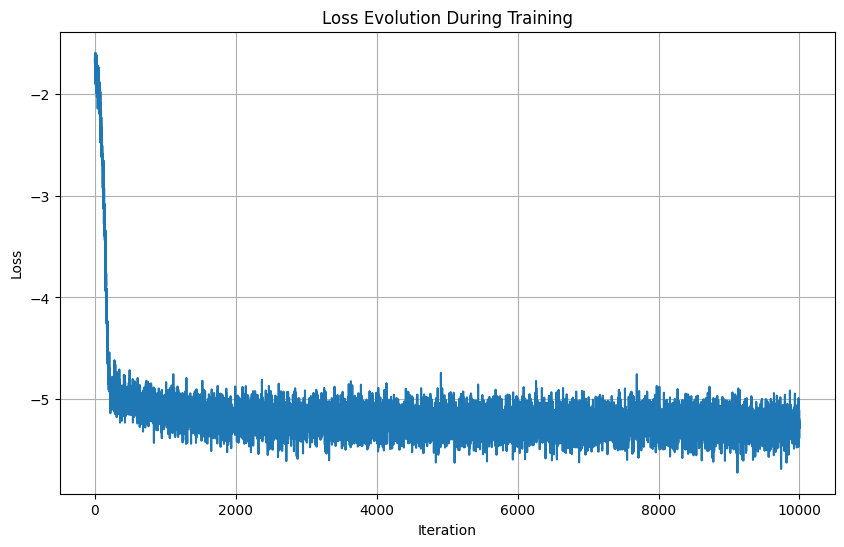

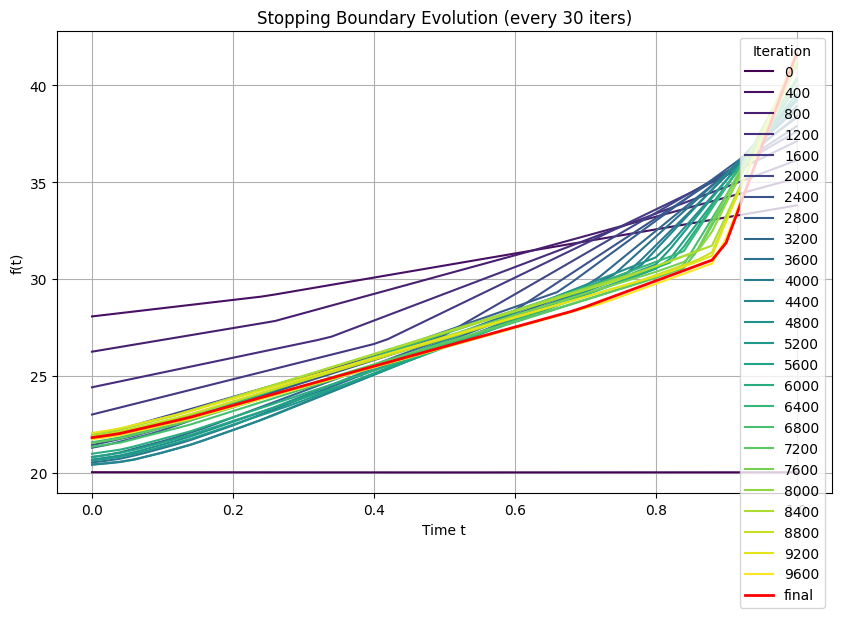

In [7]:
def simulate_paths(B):
    """Simulates B paths of the underlying asset price using the Black-Scholes model."""
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    S[:, 0, 0] = K
    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    return S

def alpha_fn(x):
    """
    Extracts the alpha coordinate from the state variable x.

    In this implementation for 1D option, alpha(x) corresponds to the underlying asset price,
    which is assumed to be the first (and only) feature in the state vector.
    """
    return x[:, [0]]

def Xi_fn(x):
    """Stopping boundary depends only on time"""
    return torch.zeros((x.shape[0], 1), dtype=torch.float32)


def phi_fn(t, x, r):
    """Computes the payoff function for the Put Option

    Args:
        t: Current time
        x: State variable (in this case, the stock price)
        r: Risk-free interest rate
    """
    S = x[:, [0]]
    return F.relu(K - S) * np.exp(-r * t) 

# Training parameters
eta = -1
eps = K * sigma * np.sqrt(dt)
bias0 = K / 2
latent_dim = 1
batch_size = 2048
n_iters = 10000
learning_rate = 1e-3

# Train
model_put = deep_erm_training(simulate_paths,
                          alpha_fn, Xi_fn, phi_fn,
                          eta, eps, bias0,
                          latent_dim,
                          batch_size, n_iters,
                          learning_rate,
                          t_grid, r)

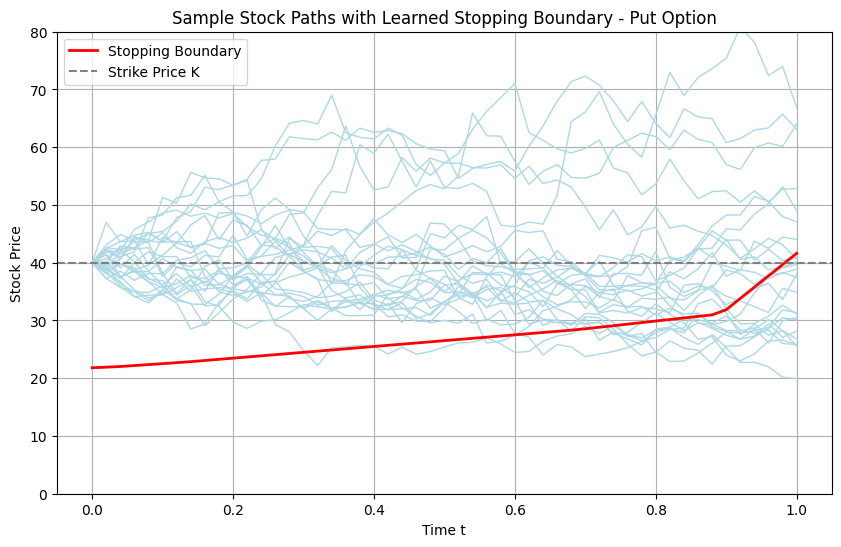

In [8]:
plot_paths_with_boundary(model_put, simulate_paths, t_grid, K, name="Put Option")

### 1D Put Option - Importance sampling

In [9]:
# TODO: Implement importance sampling for the Put Option


In [10]:
# plot_paths_with_boundary(model_put_importance, simulate_paths, t_grid, K, name="Put Option")

### 1D Call Option

Modify phi_fn, eta, bias0 between Put and Call

Training: 100%|██████████| 10000/10000 [13:03<00:00, 12.77it/s, loss=-7.293945]


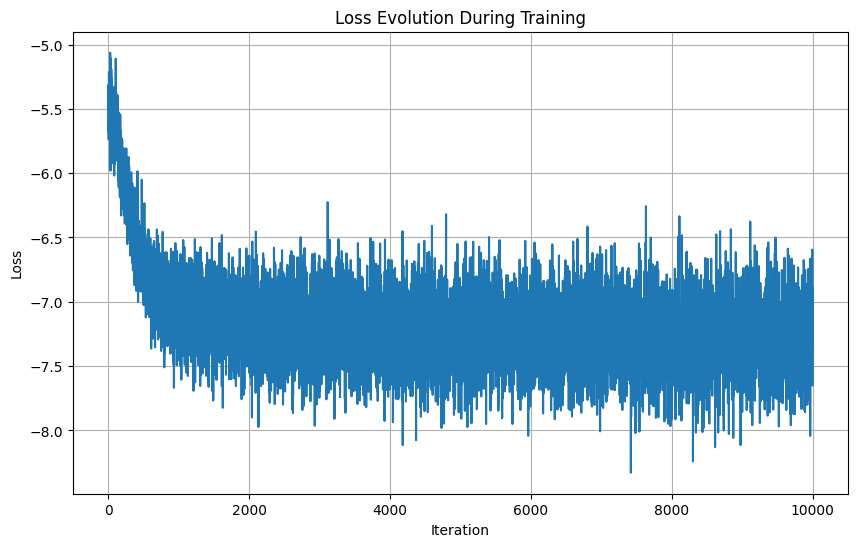

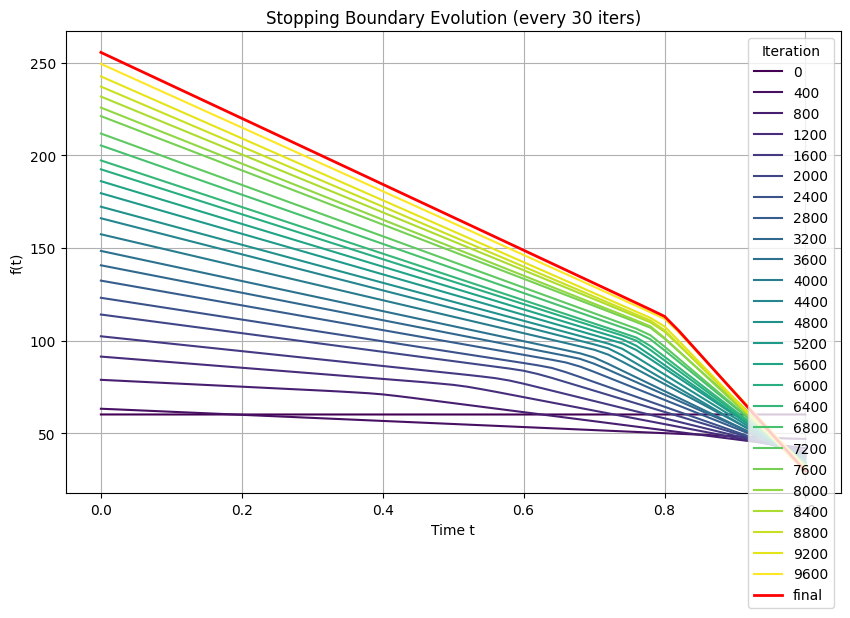

In [11]:
def simulate_paths(B):
    """Simulates B paths of the underlying asset price using the Black-Scholes model."""
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    S[:, 0, 0] = K
    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    return S

def alpha_fn(x):
    """
    Extracts the alpha coordinate from the state variable x.

    In this implementation for 1D option, alpha(x) corresponds to the underlying asset price,
    which is assumed to be the first (and only) feature in the state vector.
    """
    return x[:, [0]]

def Xi_fn(x):
    """Stopping boundary depends only on time"""
    return torch.zeros((x.shape[0], 1), dtype=torch.float32)


def phi_fn(t, x, r):
    """Computes the payoff function for the Call Option

    Args:
        t: Current time
        x: State variable (in this case, the stock price)
        r: Risk-free interest rate
    """
    S = x[:, [0]]
    return F.relu(S - K) * np.exp(-r * t) 

# Training parameters
eta = 1
eps = K * sigma * np.sqrt(dt)
bias0 = 1.5 * K
latent_dim = 1
batch_size = 2048
n_iters = 10000
learning_rate = 1e-3

# Train
model_call = deep_erm_training(simulate_paths,
                          alpha_fn, Xi_fn, phi_fn,
                          eta, eps, bias0,
                          latent_dim,
                          batch_size, n_iters,
                          learning_rate,
                          t_grid, r)

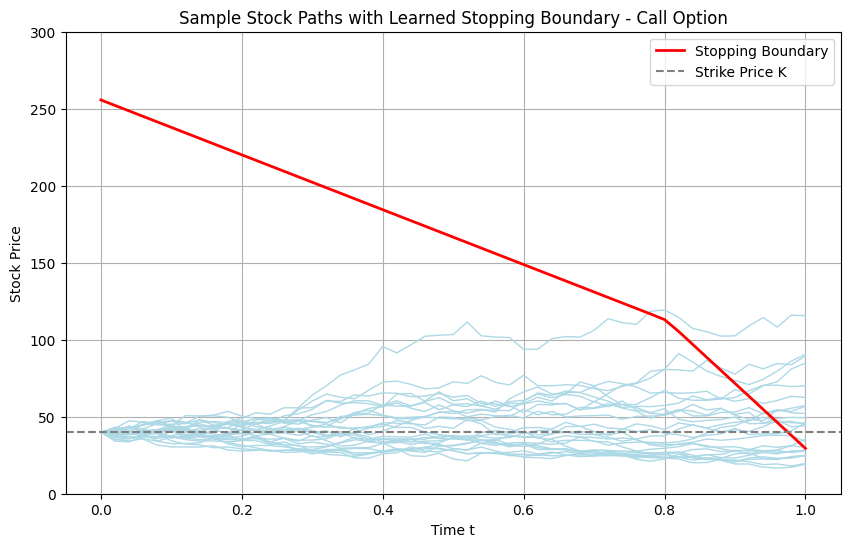

In [12]:
plot_paths_with_boundary(model_call, simulate_paths, t_grid, K, ylim=(0, 300), name="Call Option")